This notebook is for performing exploratory data analysis on the SemEval dataset

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

In [2]:
BASE_DIR = Path("..").resolve()
# Pull the merged TC (Technique Classification) data
semeval = pd.read_csv(BASE_DIR / "data" / "processed" / "semeval_tc_cleaned.csv")

In [3]:
if "start_char" in semeval.columns and "end_char" in semeval.columns:
    # Calculate span length if not already calculated
    semeval["span_length"] = semeval["end_char"] - semeval["start_char"]
elif "span_text" in semeval.columns:
    # If already calculated, convert span text to string and calculate length
    semeval["span_length"] = semeval["span_text"].astype(str).str.len()
else:
    raise KeyError(
        "Could not compute span_length: expected either start_char/end_char or span_text."
    )
print(f"Total examples: {len(semeval)}")

Total examples: 7587


In [4]:
# Define the one-hot propaganda technique columns
technique_cols = [
    col
    for col in semeval.columns
    if col
    not in {
        "article_id",
        "text_content",
        "span_text",
        "start_char",
        "end_char",
        "sentiment",
        "punct_count",
        "lexical_diversity",
        "span_length",
    }
]

In [5]:
plot_rows = []
# Build long form dataframe for visualization only where each technique becomes its own row
for _, row in semeval.iterrows():
    active_techniques = [col for col in technique_cols if row.get(col, 0) == 1]
    if not active_techniques:
        plot_rows.append(
            {
                "article_id": row["article_id"],
                "span_text": row["span_text"],
                "span_length": row["span_length"],
                "technique_label": "Unknown",
            }
        )
    else:
        for technique in active_techniques:
            plot_rows.append(
                {
                    "article_id": row["article_id"],
                    "span_text": row["span_text"],
                    "span_length": row["span_length"],
                    "technique_label": technique,
                }
            )

semeval_plot = pd.DataFrame(plot_rows)
# Remove negative samples added for downstream training—these are not actual propaganda examples, they're examples of non-propaganda
semeval_plot = semeval_plot[semeval_plot["technique_label"] != "Unknown"]
semeval_plot.head()

,article_id,span_text,span_length,technique_label
0,111111111,appeared,8,Doubt
1,111111111,The next transmission could be more pronounced...,58,Appeal_to_Authority
2,111111111,"a very, very different",22,Repetition
3,111111111,He also pointed to the presence of the pneumon...,128,Appeal_to_fear-prejudice
4,111111111,but warned that the danger was not over,39,Appeal_to_fear-prejudice


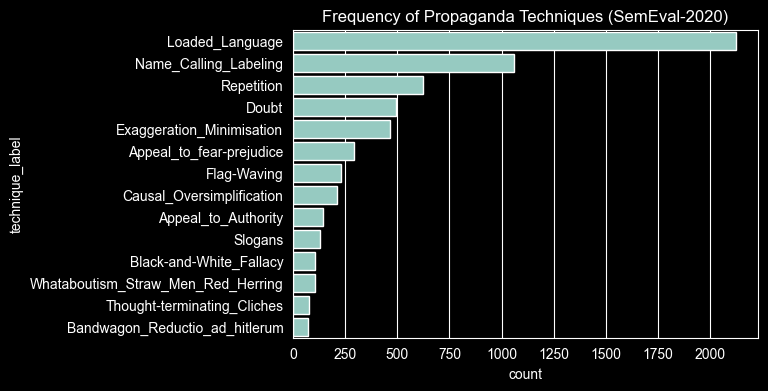

In [6]:
# Visualize frequency of different propaganda techniques
file_name = BASE_DIR / "reports/figures/technique_frequencies.png"

plt.figure(figsize=(6, 4))
sns.countplot(
    data=semeval_plot,
    y="technique_label",
    order=semeval_plot["technique_label"].value_counts().index,
)
plt.title("Frequency of Propaganda Techniques (SemEval-2020)")

plt.savefig(file_name, bbox_inches="tight")
plt.show()

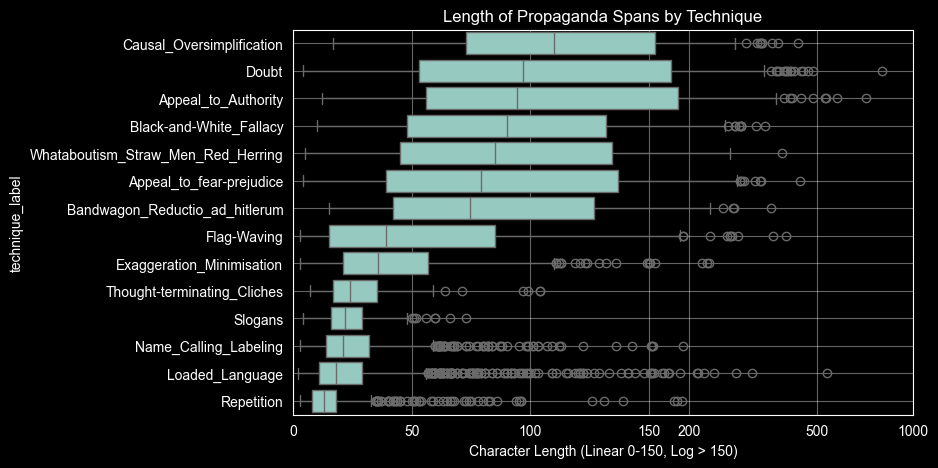

In [7]:
file_name = BASE_DIR / "reports/figures/spans_by_technique.png"

technique_order = (
    semeval_plot.groupby("technique_label")["span_length"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=semeval_plot, x="span_length", y="technique_label", order=technique_order
)
plt.xscale("symlog", linthresh=150)
plt.xlim(left=0)
ticks = [0, 50, 100, 150, 200, 500, 1000]
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(ScalarFormatter())

plt.title("Length of Propaganda Spans by Technique")
plt.xlabel("Character Length (Linear 0-150, Log > 150)")
plt.grid(True, which="both", ls="-", alpha=0.4)

plt.savefig(file_name, bbox_inches="tight")
plt.show()